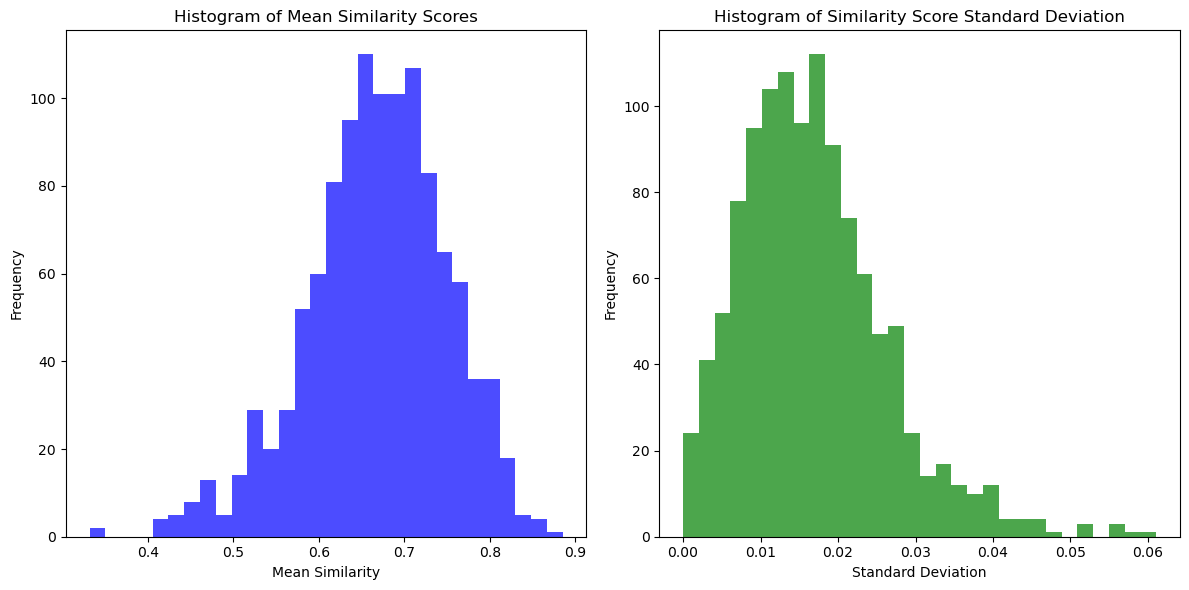

Overall mean similarity: 0.6677
Overall std similarity: 0.0846

Best molecule:
original_smile            Cc1c(C2CC2)nc2ccc(NC(=O)c3ccc(-c4ccccn4)cc3)cn12
mean_similarity                                                   0.885239
std_similarity                                                    0.020307
max_similarity                                                    0.922725
max_similarity_smile     O=C(NCCNC(=O)C1=CN=CC=N1)C(=O)N1CCCC(C(=O)N2CC...
is_max_smile_original                                                False
Name: 744, dtype: object

Worst molecule:
original_smile           CSc1ccc(-c2ccn(-c3ccc4c5c(n(C)c4c3)CNCC5)c(=O)...
mean_similarity                                                   0.331869
std_similarity                                                    0.019467
max_similarity                                                    0.385548
max_similarity_smile     COC(=O)[C@H](CC1=CN=CN1C)NC(=O)C(CC1=CC=CC=C1)...
is_max_smile_original                                 

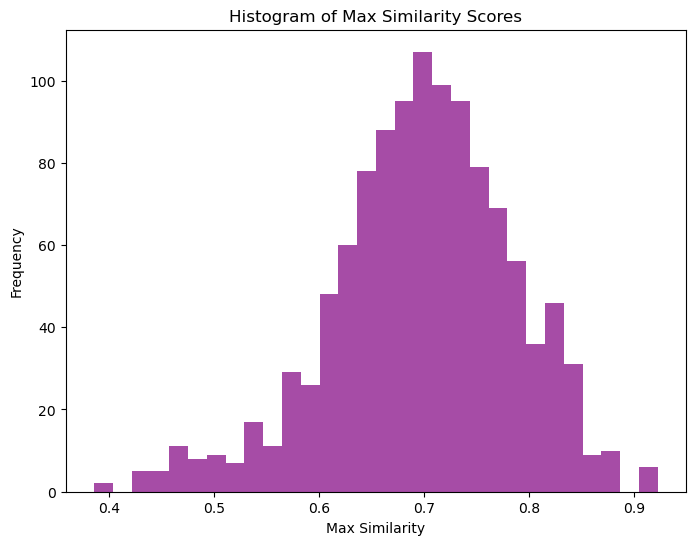

Proportion of max similarity smiles in original set: 0.0000


In [1]:
import os
import pickle
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the result_dict
from collections import defaultdict

dir = "/nethome/pjajoria/Github/Tox21Noisy/outputs/similar_molecules/checkpoints"
a = os.walk(dir)
result_dict = defaultdict(list)
for root, dirs, files in a:
    for file in files:
        if file.startswith("similar_molecules"):
            continue
        with open(os.path.join(root, file), 'rb') as f:
            file_dict = pickle.load(f)
            for smile, value in file_dict['heap_dict'].items():
                result_dict[smile].extend(value)

# Prepare data for analysis
summary_data = []
all_similarities = []
original_smiles = set(result_dict.keys())

for original_smile, similar_molecules in result_dict.items():
    scores = [x[0] for x in similar_molecules]
    smiles = [x[1] for x in similar_molecules]
    summary_data.append({
        "original_smile": original_smile,
        "mean_similarity": np.mean(scores),
        "std_similarity": np.std(scores),
        "max_similarity": np.max(scores),
        "max_similarity_smile": smiles[np.argmax(scores)]
    })
    all_similarities.extend(scores)

# Convert summary to DataFrame
summary_df = pd.DataFrame(summary_data)

# Add flag to check if max similarity smile is part of the original list
summary_df["is_max_smile_original"] = summary_df["max_similarity_smile"].apply(lambda x: x in original_smiles)

# Visualizations and statistics
plt.figure(figsize=(12, 6))

# 1. Histogram of mean similarity scores
plt.subplot(1, 2, 1)
plt.hist(summary_df["mean_similarity"], bins=30, color='blue', alpha=0.7)
plt.title("Histogram of Mean Similarity Scores")
plt.xlabel("Mean Similarity")
plt.ylabel("Frequency")

# 2. Histogram of standard deviation of similarity scores
plt.subplot(1, 2, 2)
plt.hist(summary_df["std_similarity"], bins=30, color='green', alpha=0.7)
plt.title("Histogram of Similarity Score Standard Deviation")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3. Overall statistics
overall_mean = np.mean(all_similarities)
overall_std = np.std(all_similarities)

print(f"Overall mean similarity: {overall_mean:.4f}")
print(f"Overall std similarity: {overall_std:.4f}")

# 4. Molecules with best and worst aggregated similarity scores
best_molecule = summary_df.loc[summary_df['mean_similarity'].idxmax()]
worst_molecule = summary_df.loc[summary_df['mean_similarity'].idxmin()]

print("\nBest molecule:")
print(best_molecule)
print("\nWorst molecule:")
print(worst_molecule)

# 5. Max similarity molecule and its status
max_similarity_row = summary_df.loc[summary_df["max_similarity"].idxmax()]
print("\nMolecule with highest similarity:")
print(max_similarity_row)

# 6. Additional statistics: distribution of max similarity
plt.figure(figsize=(8, 6))
plt.hist(summary_df["max_similarity"], bins=30, color='purple', alpha=0.7)
plt.title("Histogram of Max Similarity Scores")
plt.xlabel("Max Similarity")
plt.ylabel("Frequency")
plt.show()

# 7. Proportion of max similarity smiles that are part of the original set
proportion_original = summary_df["is_max_smile_original"].mean()
print(f"Proportion of max similarity smiles in original set: {proportion_original:.4f}")


In [5]:
import joblib
# Load the pre-trained RandomForest model from the .joblib file
model = joblib.load("/nethome/pjajoria/Github/Tox21Noisy/models/rf_classification_morgan_fp.joblib")

# Load the DataFrame
df = pd.read_pickle("/nethome/pjajoria/Github/Tox21Noisy/outputs/similar_molecules/old_checkpoints/Complete Run/similar_molecules_dataframe.pkl")
X_similar = np.array(df["Fingerprint"].tolist())
# predictions = model.predict(X_similar)

# X_similar_np = X_similar.numpy()

# Get prediction probabilities
probabilities = model.predict_proba(X_similar)

# Define a custom threshold (e.g., 0.6)
custom_threshold = 0.40

df["RandomForestLabels"] = (probabilities[:, 1] >= custom_threshold)

In [ ]:
# Define a custom threshold (e.g., 0.6)
custom_threshold = 0.40

df["RandomForestLabels"] = (probabilities[:, 1] >= custom_threshold)
df[df["RandomForestLabels"] == True].sort_values(by=['SimilarityScore'], ascending=False)

In [24]:
import sys
import os
# Add the root directory to the sys.path
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Assuming the root is one level up
sys.path.append(root_dir)

In [29]:
from data_prep import smiles_to_morgan_fingerprint

# Dataset preparation
data_path = '/nethome/pjajoria/Github/Tox21Noisy/benchmark_datasets/CACHE5/20240430_MCHR1_splitted_RJ.csv'
data = pd.read_csv(data_path, index_col=0)

# Convert SMILES to Morgan fingerprints
data["morgan_fp"] = list(map(smiles_to_morgan_fingerprint, data['smiles'].values))
x_cache = np.array(data["morgan_fp"].tolist())
cache_prob = model.predict_proba(x_cache)
data["RandomForestLabels"] = (cache_prob[:, 1] >= 0.5)

In [ ]:
# Define a custom threshold (e.g., 0.6)
custom_threshold = 0.50

data["RandomForestLabels"] = (cache_prob[:, 1] >= 0.5)
data[data["RandomForestLabels"] == True]

In [31]:
X_cache_similar = np.array(list(map(smiles_to_morgan_fingerprint, df["ParentSmile"].tolist())))
# predictions = model.predict(X_similar)

# X_similar_np = X_similar.numpy()

# Get prediction probabilities
probabilities = model.predict_proba(X_cache_similar)

# Define a custom threshold (e.g., 0.6)
custom_threshold = 0.5

df["ParentLabels"] = (probabilities[:, 1] >= custom_threshold)

In [33]:
df[df["RandomForestLabels"] == True].sort_values(by=['SimilarityScore'], ascending=False)

,SMILES,ParentSmile,SimilarityScore,Fingerprint,RandomForestLabels,ParentLabels
27126,COCC1(C(NCCC2=NN(C)C=N2)C2=NN=NN2C2CCC(F)(F)CC...,COc1ccc2c(C)cc(N[C@H]3CC[C@H](NCc4cn(C)c5ccccc...,0.611111,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",True,False
4483,CC1=C(C(=O)NCC2=C3CN(C(=O)CN4C=NN=N4)CCN3N=C2)...,COc1ccc2c(C)cc(N[C@H]3CCC[C@H](NCc4cccc(OC(F)(...,0.546667,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
4486,CC1=C(C(=O)NCC2=C3CN(C(=O)CN4C=NN=N4)CCN3N=C2)...,COc1ccc2c(C)cc(N[C@H]3CCC[C@H](NCc4cccc(OC(F)(...,0.546667,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
28091,COC(C)C(=O)NC1=CC=CC(NC(CC2CCCC(C)(C)O2)C2=NN=...,CN(c1nc2ccc(NC(=O)CCc3ccc(C(F)(F)F)cc3)cc2[nH]...,0.546667,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
28090,COC(C)C(=O)NC1=CC=CC(NC(CC2CCCC(C)(C)O2)C2=NN=...,CN(c1nc2ccc(NC(=O)CCc3ccc(C(F)(F)F)cc3)cc2[nH]...,0.546667,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
...,...,...,...,...,...,...
34509,CCC(C(=O)NCC(CNC(=O)C1=CC(C)=NN1C1CC1)S(C)(=O)...,O=c1c2cc(-c3ccc(Cl)cc3)oc2ccn1-c1ccc2c(cnn2CCN...,0.356322,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
34498,CN1N=C2CCCC2=C1C(NCC1=CN=C2C=CC=CN12)C1=NN=NN1...,O=c1c2cc(-c3ccc(Cl)cc3)oc2ccn1-c1ccc2c(cnn2CCN...,0.352273,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
34225,CC(C)(C)C1=CSC(CCNC(C)(CCS(C)(=O)=O)C2=NN=NN2C...,Cn1c2c(c3ccc(-n4ccc(-c5ccccc5)cc4=O)cc31)CNCC2,0.352113,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,False
17164,CC1=CC=C(NC2(C3=NN=NN3C3CCOCC3)CCC2)C=C1S(=O)(...,CN1CCN(CCCN(c2nc3cc(F)c(F)cc3[nH]2)[C@@H]2CC[C...,0.351064,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True,True


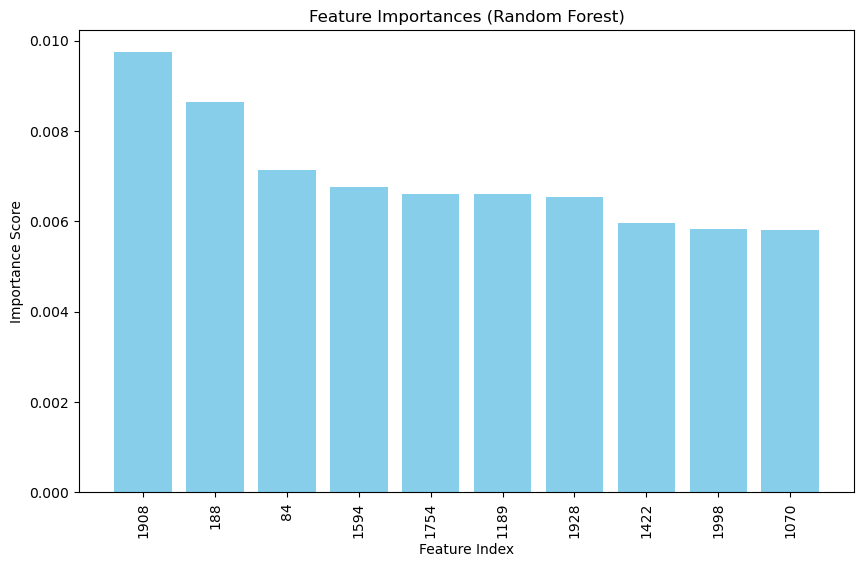

In [58]:
# Extract feature importances
feature_importances = model.feature_importances_

# Sort and plot the most important features
indices = np.argsort(feature_importances)[::-1]  # Sort in descending order
top_k = 10  # Number of features to visualize
top_indices = indices[:top_k]

plt.figure(figsize=(10, 6))
plt.bar(range(top_k), feature_importances[top_indices], align='center', color='skyblue')
plt.xticks(range(top_k), top_indices, rotation=90)  # Replace with feature names if available
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

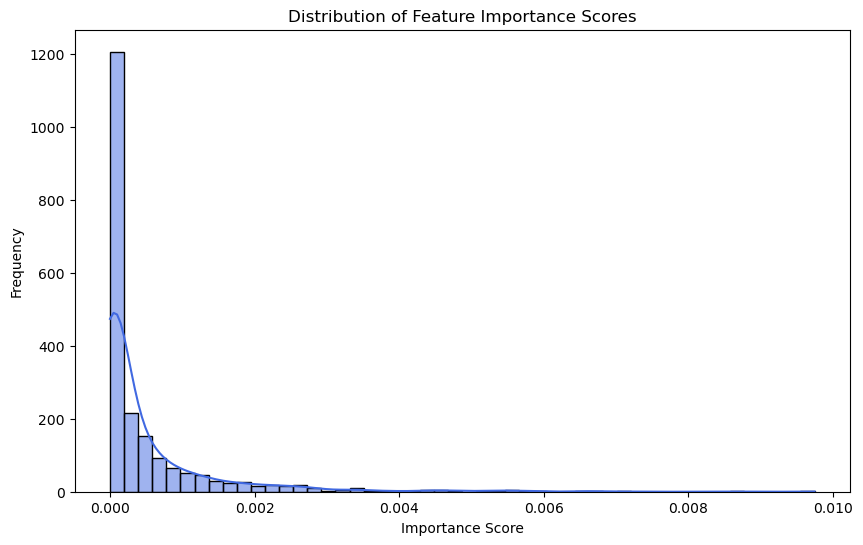

In [44]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot histogram and KDE for feature importances
sns.histplot(feature_importances, bins=50, kde=True, color="royalblue")

plt.title("Distribution of Feature Importance Scores")
plt.xlabel("Importance Score")
plt.ylabel("Frequency")
plt.show()

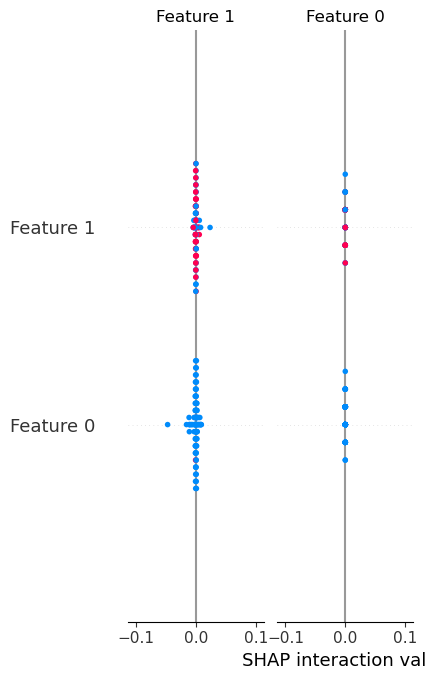

In [54]:
import shap

# Create a SHAP explainer for the RF model
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(x_cache[:100])

# Visualize summary plot for a specific class (e.g., class 1)
shap.summary_plot(shap_values, x_cache[100:200], plot_type="bar")

In [47]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 4.6 MB/s eta 0:00:000m eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 5.6 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 2.2 MB/s eta 0:00:000m eta 0:00:010:00:01
